# Supplementary Experiments: Bias, Mixing, and Variance Reduction

These three studies extend the core notebooks with reference methods, parameter
sweeps, independent repetitions, and a counterexample. The goal is to test the
size and source of numerical error, including situations where a familiar
conclusion fails. All printed values and figures are produced by the cells below.

## 1. Problem

1. **OU discretization:** Does Euler–Maruyama reproduce the continuous OU
   variance when the step is coarse? Does refining the step reduce its bias?
   Compare it with the exact Gaussian transition law at a fixed final time.
2. **Markov mixing:** How does the transition probability change convergence
   speed? Can a chain have a unique stationary distribution yet fail to converge
   to it from a fixed state?
3. **Monte Carlo efficiency:** Can a control variate reduce RMSE at the same
   evaluation sample count? Do nominal 95% confidence intervals actually contain
   the target in approximately 95% of independent replications?

## 2. Mathematical Background

**OU.** Solving the linear SDE over one step $h$ gives

$$X_{t+h}=\mu+e^{-\theta h}(X_t-\mu)
+\sigma\int_t^{t+h} e^{-\theta(t+h-s)}\,dW_s.$$

The integral is independent of $X_t$, Gaussian, and has variance
$(1-e^{-2\theta h})/(2\theta)$. This supplies an exact transition benchmark
at grid points. Euler instead replaces the exponential decay by $1-\theta h$.

**Markov.** For the symmetric two-state matrix

$$P_\alpha=\begin{pmatrix}1-\alpha&\alpha\\\alpha&1-\alpha\end{pmatrix},$$

the eigenvalues are $1$ and $1-2\alpha$. The stationary distribution is
$\pi=(1/2,1/2)$ for $\alpha>0$. Total variation distance on a finite state space is
$d_{\rm TV}(p,q)=\tfrac12\sum_i|p_i-q_i|$.

**Control variate.** Write $f(U)=e^{-U^2}$, $g(U)=U^2$ for
$U\sim\mathrm{Uniform}(0,1)$, so $E[g(U)]=1/3$. Subtracting a centered correlated
quantity preserves the target mean: $Y_\beta=f(U)-\beta(g(U)-1/3)$.

## 3. Theoretical Result

### OU: continuous theory versus the discretized recursion

For deterministic $X_0=x_0$, at $T=kh$ the continuous variance is

$$v(T)=\frac{\sigma^2}{2\theta}(1-e^{-2\theta T}).$$

Putting $a=1-\theta h$, the Euler variance is

$$v_h(T)=\sigma^2h\sum_{j=0}^{k-1}a^{2j}.$$

The Euler stationary variance is $\sigma^2/(2\theta-\theta^2h)$ when
$0<\theta h<2$, with relative stationary bias $\theta h/(2-\theta h)$.
Thus increasing the number of paths at fixed $h$ cannot remove this bias.
At fixed $T$, $v_h(T)-v(T)=O(h)$ as $h\to0$. This is a **moment bias** statement;
we do not measure pathwise strong convergence in this notebook.

### Markov: speed and a counterexample

Starting in state 0,

$$P(X_n=0)=\frac12+\frac12(1-2\alpha)^n,
\qquad d_{\rm TV}(\mathcal L(X_n),\pi)=\frac12|1-2\alpha|^n.$$

For $0<\alpha<1$, both states communicate and the chain has self-loops,
so it is irreducible and aperiodic. At $\alpha=1$ it alternates deterministically:
the stationary distribution still exists and is unique, but the distance remains
$1/2$. Time-averaged occupancy can nevertheless approach $1/2$.

### Monte Carlo: reduced constant, unchanged rate

$$\mathrm{Var}(Y_\beta)=\mathrm{Var}(f)+\beta^2\mathrm{Var}(g)
-2\beta\mathrm{Cov}(f,g),\qquad
\beta^*=\frac{\mathrm{Cov}(f,g)}{\mathrm{Var}(g)}.$$

Estimate $\beta$ from a **separate 5,000-point pilot**, then freeze it before
evaluation. Conditional on this pilot, each evaluation estimate is unbiased.
Both methods have RMSE $\sqrt{\mathrm{Var}(Y)/N}$; a control variate reduces
the constant, not the $N^{-1/2}$ order. Use independent rows to assess the
coverage of $\widehat I\pm1.96\widehat{\mathrm{SE}}$.

Reference material: [Higham (2001), numerical SDE simulation](https://doi.org/10.1137/S0036144500378302),
[Oxford, finite Markov chains and mixing](https://www.cs.ox.ac.uk/people/elias.koutsoupias/pc2016-17/lectures.html),
and [Haugh, Monte Carlo lecture notes](https://www.columbia.edu/~mh2078/MonteCarlo.html).
The model-specific formulas above follow directly from the displayed recursions.

## 4. Numerical Experiment

In [1]:
from pathlib import Path
import sys
import json
import platform
import numpy as np
import scipy
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import Image, display
from scipy.integrate import quad
from scipy.special import erf
from scipy.stats import chi2

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent
assert (project_root / "src/ou_process.py").exists(), "Run from repository root or notebooks/"
sys.path.insert(0, str(project_root))
from src.ou_process import simulate_ou_euler, simulate_ou_exact, ou_euler_moments, ou_mean, ou_variance
from src.markov_chain import simulate_chains, stationary_distribution, total_variation_distance
from src.monte_carlo import replicate_control_variate_integrals, root_mean_squared_error

figure_dir = project_root / "figures"
figure_dir.mkdir(exist_ok=True)
results = {"versions": {"python": platform.python_version(), "numpy": np.__version__,
                       "scipy": scipy.__version__, "matplotlib": matplotlib.__version__}}

def save_figure(fig, name):
    fig.tight_layout()
    path = figure_dir / name
    fig.savefig(path, dpi=160)
    plt.close(fig)
    display(Image(filename=str(path)))

### A. OU step refinement

Hold $T=4$, $\theta=0.7$, $\mu=1.5$, $\sigma=0.8$, and $x_0=-1$ fixed.
Use six steps from $1$ to $1/32$. For every method/step combination pool
three independent batches of 20,000 endpoints (60,000 paths total).
All seeds are recorded below. Euler and exact runs use independent streams;
their path differences are not a strong-error estimator.

Gaussian endpoints permit exact pointwise 95% variance confidence intervals:
$[(M-1)s^2/\chi^2_{.975,M-1},(M-1)s^2/\chi^2_{.025,M-1}]$.
These quantify sampling uncertainty around **each method's own variance**.

In [2]:
theta, mu, sigma, x0, horizon = .7, 1.5, .8, -1., 4.
steps = np.array([1., .5, .25, .125, .0625, .03125])
batch_paths, batches = 20_000, 3
ou_rows, ou_seeds = [], []
continuous_mean = float(ou_mean(horizon, theta, mu, x0))
continuous_variance = float(ou_variance(horizon, theta, sigma))
for step_index, dt in enumerate(steps):
    n_steps = int(round(horizon / dt))
    for method_index, (method, simulator) in enumerate([
        ("Euler", simulate_ou_euler), ("Exact", simulate_ou_exact)
    ]):
        endpoint_batches = []
        for batch_index in range(batches):
            seed = 61000 + 100 * step_index + 10 * method_index + batch_index
            ou_seeds.append(seed)
            paths = simulator(theta, mu, sigma, x0, float(dt), n_steps,
                              batch_paths, np.random.default_rng(seed))
            endpoint_batches.append(paths[:, -1].copy())
            del paths
        endpoints = np.concatenate(endpoint_batches)
        sample_variance = float(endpoints.var(ddof=1))
        df = endpoints.size - 1
        lower = df * sample_variance / chi2.ppf(.975, df)
        upper = df * sample_variance / chi2.ppf(.025, df)
        method_mean, method_variance = (
            ou_euler_moments(theta, mu, sigma, x0, float(dt), n_steps)
            if method == "Euler" else (continuous_mean, continuous_variance)
        )
        ou_rows.append(dict(method=method, dt=float(dt), sample_mean=float(endpoints.mean()),
                           theory_mean=method_mean, sample_variance=sample_variance,
                           theory_variance=method_variance, ci_lower=float(lower), ci_upper=float(upper)))
print(f"Continuous target at T={horizon}: mean={continuous_mean:.6f}, variance={continuous_variance:.6f}")
print("method     dt     empirical variance   method theory     95% variance interval")
for row in ou_rows:
    print(f"{row['method']:6s} {row['dt']:7.5f}   {row['sample_variance']:.6f}             "
          f"{row['theory_variance']:.6f}       [{row['ci_lower']:.6f}, {row['ci_upper']:.6f}]")
fine_steps = steps[steps <= .125]
fine_bias = np.array([abs(ou_euler_moments(theta, mu, sigma, x0, float(h),
                    int(round(horizon/h)))[1] - continuous_variance) for h in fine_steps])
ou_slope = float(np.polyfit(np.log(fine_steps), np.log(fine_bias), 1)[0])
print(f"Analytic finite-time variance-bias slope on h <= .125: {ou_slope:.4f}")
results['ou'] = dict(theta=theta, mu=mu, sigma=sigma, x0=x0, horizon=horizon,
                     paths_per_combination=batch_paths*batches, batches=batches, seeds=ou_seeds,
                     target_mean=continuous_mean, target_variance=continuous_variance,
                     analytic_bias_slope=ou_slope, rows=ou_rows)

Continuous target at T=4.0: mean=1.347975, variance=0.455452
method     dt     empirical variance   method theory     95% variance interval
Euler  1.00000   0.699773             0.703251       [0.691922, 0.707760]
Exact  1.00000   0.453507             0.455452       [0.448419, 0.458683]
Euler  0.50000   0.549121             0.553550       [0.542960, 0.555389]
Exact  0.50000   0.455128             0.455452       [0.450021, 0.460322]
Euler  0.25000   0.495575             0.499916       [0.490015, 0.501231]
Exact  0.25000   0.451771             0.455452       [0.446702, 0.456927]
Euler  0.12500   0.482806             0.476695       [0.477389, 0.488317]
Exact  0.12500   0.462453             0.455452       [0.457265, 0.467731]
Euler  0.06250   0.465687             0.465843       [0.460462, 0.471002]
Exact  0.06250   0.457915             0.455452       [0.452777, 0.463142]
Euler  0.03125   0.461294             0.460592       [0.456118, 0.466558]
Exact  0.03125   0.451592             0.455452

### B. Markov mixing, slow mixing, and periodicity

Sweep $\alpha\in\{0.2,0.02,1\}$ and both starting states.
For each combination pool five independently seeded batches of 10,000 paths
over 160 steps. Compare empirical marginal probabilities and total variation
distance with the exact formulas. The 95% probability intervals shown later
are Wilson intervals at each time, not a simultaneous confidence band.

In [3]:
alphas = [.2, .02, 1.]
markov_steps, markov_batch_paths, markov_batches = 160, 10_000, 5
times = np.arange(markov_steps + 1)
markov_runs, markov_seeds = [], []
for alpha_index, alpha in enumerate(alphas):
    matrix = np.array([[1-alpha, alpha], [alpha, 1-alpha]])
    stationary = stationary_distribution(matrix)
    for initial_state in (0, 1):
        state_zero_counts = np.zeros(markov_steps + 1, dtype=int)
        for batch_index in range(markov_batches):
            seed = 62000 + 100*alpha_index + 10*initial_state + batch_index
            markov_seeds.append(seed)
            paths = simulate_chains(matrix, initial_state, markov_steps,
                                    markov_batch_paths, np.random.default_rng(seed))
            state_zero_counts += (paths == 0).sum(axis=0)
            del paths
        count = markov_batch_paths * markov_batches
        empirical = state_zero_counts / count
        theory = .5 + (.5 if initial_state == 0 else -.5) * (1-2*alpha)**times
        empirical_tv = np.array([total_variation_distance(np.array([p, 1-p]), stationary)
                                 for p in empirical])
        theoretical_tv = .5 * abs(1-2*alpha)**times
        # Wilson score intervals for pooled independent Bernoulli paths at each time.
        z = 1.959963984540054
        center = (empirical + z*z/(2*count))/(1+z*z/count)
        half_width = z*np.sqrt(empirical*(1-empirical)/count + z*z/(4*count*count))/(1+z*z/count)
        markov_runs.append(dict(alpha=alpha, initial_state=initial_state,
                               empirical=empirical, theory=theory,
                               empirical_tv=empirical_tv, theoretical_tv=theoretical_tv,
                               lower=center-half_width, upper=center+half_width))
        print(f"alpha={alpha:.2f}, start={initial_state}, P(X_160=0): "
              f"empirical={empirical[-1]:.5f}, theory={theory[-1]:.5f}; "
              f"max marginal discrepancy={np.max(abs(empirical-theory)):.5f}")
results['markov'] = dict(steps=markov_steps, paths_per_combination=count,
    batches=markov_batches, seeds=markov_seeds, rows=[dict(
        alpha=r['alpha'], initial_state=r['initial_state'],
        max_probability_error=float(np.max(abs(r['empirical']-r['theory']))),
        endpoint_probability=float(r['empirical'][-1]),
        theoretical_endpoint_probability=float(r['theory'][-1])) for r in markov_runs])

alpha=0.20, start=0, P(X_160=0): empirical=0.49960, theory=0.50000; max marginal discrepancy=0.00724


alpha=0.20, start=1, P(X_160=0): empirical=0.50020, theory=0.50000; max marginal discrepancy=0.00584


alpha=0.02, start=0, P(X_160=0): empirical=0.49866, theory=0.50073; max marginal discrepancy=0.00482


alpha=0.02, start=1, P(X_160=0): empirical=0.50194, theory=0.49927; max marginal discrepancy=0.00450


alpha=1.00, start=0, P(X_160=0): empirical=1.00000, theory=1.00000; max marginal discrepancy=0.00000


alpha=1.00, start=1, P(X_160=0): empirical=0.00000, theory=0.00000; max marginal discrepancy=0.00000


### C. Control variates and interval coverage

The integral target $I=\sqrt\pi\,\mathrm{erf}(1)/2$ is used only for benchmarking.
An independent pilot supplies the coefficient; it does not use $I$.
Use 1,000 independent evaluation replications at each of five sample sizes.
Plain and adjusted estimates share evaluation points to make a paired comparison.
Numerical quadrature independently computes the predicted single-draw variances
for the frozen coefficient, and reports its own numerical error estimates.

In [4]:
integrand = lambda u: np.exp(-u**2)
control = lambda u: u**2
pilot_seed, evaluation_seed, pilot_size = 63000, 63001, 5_000
pilot = np.random.default_rng(pilot_seed).random(pilot_size)
coefficient = float(np.cov(integrand(pilot), control(pilot), ddof=1)[0, 1]
                    / np.var(control(pilot), ddof=1))
integral_target = float(np.sqrt(np.pi) * erf(1) / 2)
plain_variance, plain_quad_error = quad(lambda u: (np.exp(-u*u)-integral_target)**2, 0, 1)
adjusted_variance, adjusted_quad_error = quad(
    lambda u: (np.exp(-u*u)-coefficient*(u*u-1/3)-integral_target)**2, 0, 1)
sample_sizes, replications = np.array([100, 300, 1_000, 3_000, 10_000]), 1_000
evaluation_rng = np.random.default_rng(evaluation_seed)
mc_rows = []
for size in sample_sizes:
    plain, adjusted, plain_se, adjusted_se = replicate_control_variate_integrals(
        integrand, control, 1/3, coefficient, int(size), replications, evaluation_rng)
    row = dict(n=int(size))
    for name, estimates, se, variance in [
        ('plain', plain, plain_se, plain_variance),
        ('control', adjusted, adjusted_se, adjusted_variance)
    ]:
        hits = int(np.sum(np.abs(estimates-integral_target) <= 1.96*se))
        coverage = hits/replications
        # Wilson interval: uncertainty of the observed coverage fraction itself.
        z = 1.959963984540054
        center = (coverage+z*z/(2*replications))/(1+z*z/replications)
        half_width = z*np.sqrt(coverage*(1-coverage)/replications + z*z/(4*replications**2))/(1+z*z/replications)
        row[name] = dict(rmse=root_mean_squared_error(estimates, integral_target),
                         theoretical_rmse=float(np.sqrt(variance/size)),
                         bias=float(estimates.mean()-integral_target),
                         average_se=float(se.mean()), coverage=coverage,
                         coverage_lower=float(center-half_width), coverage_upper=float(center+half_width))
    row['squared_rmse_ratio'] = row['plain']['rmse']**2 / row['control']['rmse']**2
    mc_rows.append(row)
print(f"Pilot coefficient beta={coefficient:.6f}; target I={integral_target:.9f}")
print(f"Predicted plain/control variance ratio: {plain_variance/adjusted_variance:.2f}")
print(f"Quadrature error estimates: {plain_quad_error:.2e}, {adjusted_quad_error:.2e}")
print("     N     plain RMSE   control RMSE   RMSE^2 ratio   coverage (plain/control)")
for row in mc_rows:
    print(f"{row['n']:6d}     {row['plain']['rmse']:.6f}     {row['control']['rmse']:.6f}"
          f"      {row['squared_rmse_ratio']:7.2f}        "
          f"{row['plain']['coverage']:.3f}/{row['control']['coverage']:.3f}")
mc_slopes = {name: float(np.polyfit(np.log(sample_sizes),
             np.log([r[name]['rmse'] for r in mc_rows]), 1)[0]) for name in ('plain', 'control')}
print(f"Fitted RMSE slopes: {mc_slopes}")
results['monte_carlo'] = dict(pilot_seed=pilot_seed, evaluation_seed=evaluation_seed,
    pilot_size=pilot_size, replications=replications, coefficient=coefficient,
    target=integral_target, predicted_variance_ratio=plain_variance/adjusted_variance,
    quadrature_error_estimates=[plain_quad_error, adjusted_quad_error], slopes=mc_slopes, rows=mc_rows)

Pilot coefficient beta=-0.666434; target I=0.746824133
Predicted plain/control variance ratio: 66.01
Quadrature error estimates: 4.49e-16, 6.79e-18
     N     plain RMSE   control RMSE   RMSE^2 ratio   coverage (plain/control)
   100     0.020056     0.002507        63.98        0.947/0.943
   300     0.011804     0.001453        66.04        0.950/0.939
  1000     0.006361     0.000776        67.18        0.949/0.946
  3000     0.003726     0.000465        64.12        0.948/0.942
 10000     0.001925     0.000244        62.27        0.958/0.947
Fitted RMSE slopes: {'plain': -0.5074198346766693, 'control': -0.5037735981207399}


## 5. Visualization

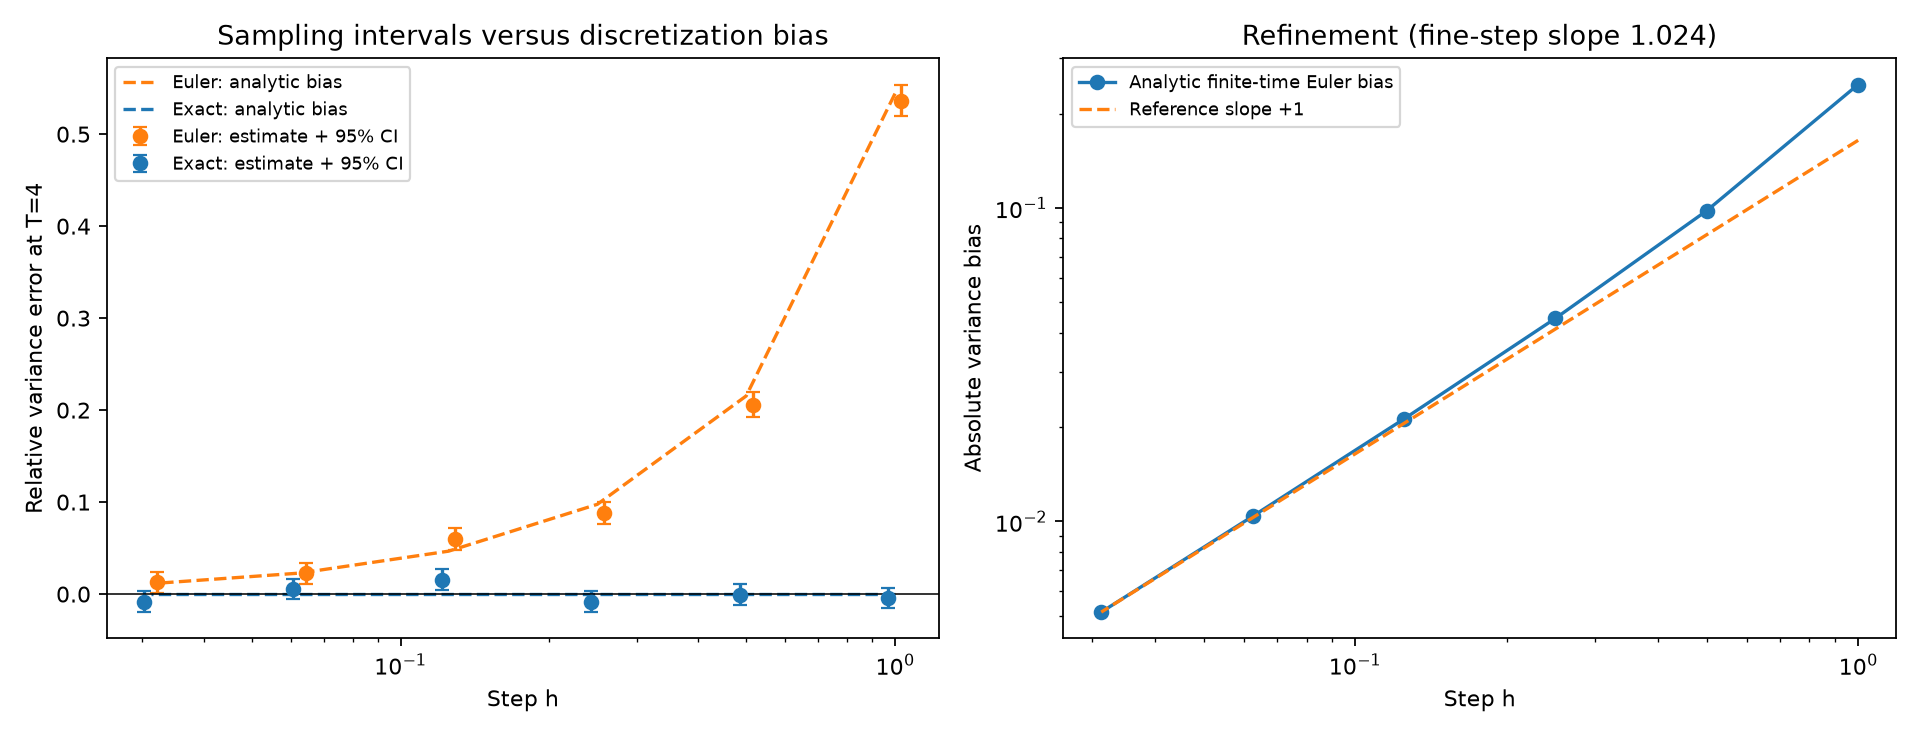

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for method, color, shift in [('Euler', 'tab:orange', 1.03), ('Exact', 'tab:blue', .97)]:
    rows = [r for r in ou_rows if r['method'] == method]
    estimates = np.array([r['sample_variance'] for r in rows])
    lower = np.array([r['ci_lower'] for r in rows])
    upper = np.array([r['ci_upper'] for r in rows])
    axes[0].errorbar(steps*shift, (estimates-continuous_variance)/continuous_variance,
                    yerr=np.array([estimates-lower, upper-estimates])/continuous_variance,
                    fmt='o', capsize=3, color=color, label=f'{method}: estimate + 95% CI')
    axes[0].plot(steps, [(r['theory_variance']-continuous_variance)/continuous_variance for r in rows],
                 '--', color=color, label=f'{method}: analytic bias')
axes[0].axhline(0, color='black', lw=.7)
axes[0].set(xscale='log', xlabel='Step h', ylabel='Relative variance error at T=4',
            title='Sampling intervals versus discretization bias')
axes[0].legend(fontsize=8)
all_bias = np.array([r['theory_variance']-continuous_variance for r in ou_rows if r['method']=='Euler'])
axes[1].loglog(steps, all_bias, 'o-', label='Analytic finite-time Euler bias')
axes[1].loglog(steps, all_bias[-1]*steps/steps[-1], '--', label='Reference slope +1')
axes[1].set(xlabel='Step h', ylabel='Absolute variance bias', title=f'Refinement (fine-step slope {ou_slope:.3f})')
axes[1].legend(fontsize=8)
save_figure(fig, 'supplementary_ou_step_refinement.png')

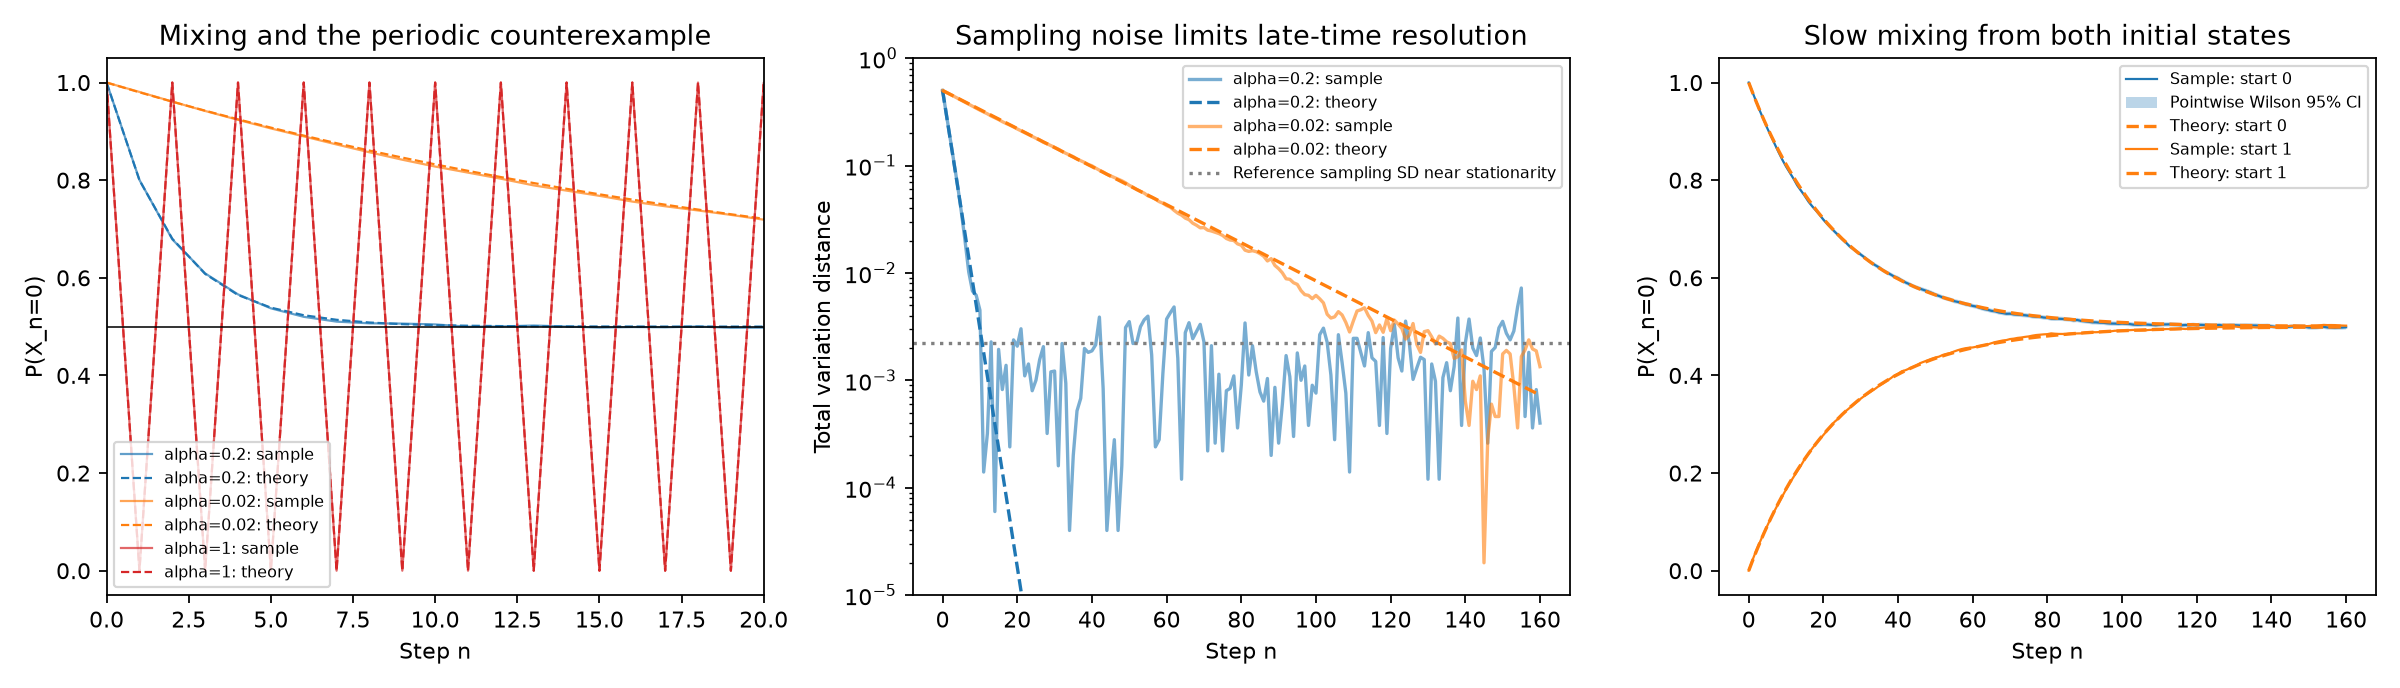

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for run, color in zip([r for r in markov_runs if r['initial_state']==0], ['tab:blue', 'tab:orange', 'tab:red']):
    alpha = run['alpha']
    axes[0].plot(times, run['empirical'], color=color, alpha=.7, lw=1, label=f'alpha={alpha:g}: sample')
    axes[0].plot(times, run['theory'], '--', color=color, lw=1, label=f'alpha={alpha:g}: theory')
    if alpha != 1:
        axes[1].semilogy(times, np.maximum(run['empirical_tv'], 1e-6), color=color, alpha=.6,
                         label=f'alpha={alpha:g}: sample')
        axes[1].semilogy(times, run['theoretical_tv'], '--', color=color, label=f'alpha={alpha:g}: theory')
slow = next(r for r in markov_runs if r['alpha']==.02 and r['initial_state']==0)
axes[2].plot(times, slow['empirical'], label='Sample: start 0', lw=1)
axes[2].fill_between(times, slow['lower'], slow['upper'], alpha=.3, label='Pointwise Wilson 95% CI')
axes[2].plot(times, slow['theory'], '--', label='Theory: start 0')
opposite = next(r for r in markov_runs if r['alpha']==.02 and r['initial_state']==1)
axes[2].plot(times, opposite['empirical'], color='tab:orange', lw=1, label='Sample: start 1')
axes[2].plot(times, opposite['theory'], '--', color='tab:orange', label='Theory: start 1')
axes[0].axhline(.5, color='black', lw=.7)
axes[0].set(xlabel='Step n', ylabel='P(X_n=0)', title='Mixing and the periodic counterexample', xlim=(0, 20))
axes[1].set(xlabel='Step n', ylabel='Total variation distance', title='Sampling noise limits late-time resolution', ylim=(1e-5, 1))
axes[1].axhline(.5/np.sqrt(count), color='gray', ls=':', label='Reference sampling SD near stationarity')
axes[2].set(xlabel='Step n', ylabel='P(X_n=0)', title='Slow mixing from both initial states')
for ax in axes:
    ax.legend(fontsize=7)
save_figure(fig, 'supplementary_markov_mixing.png')

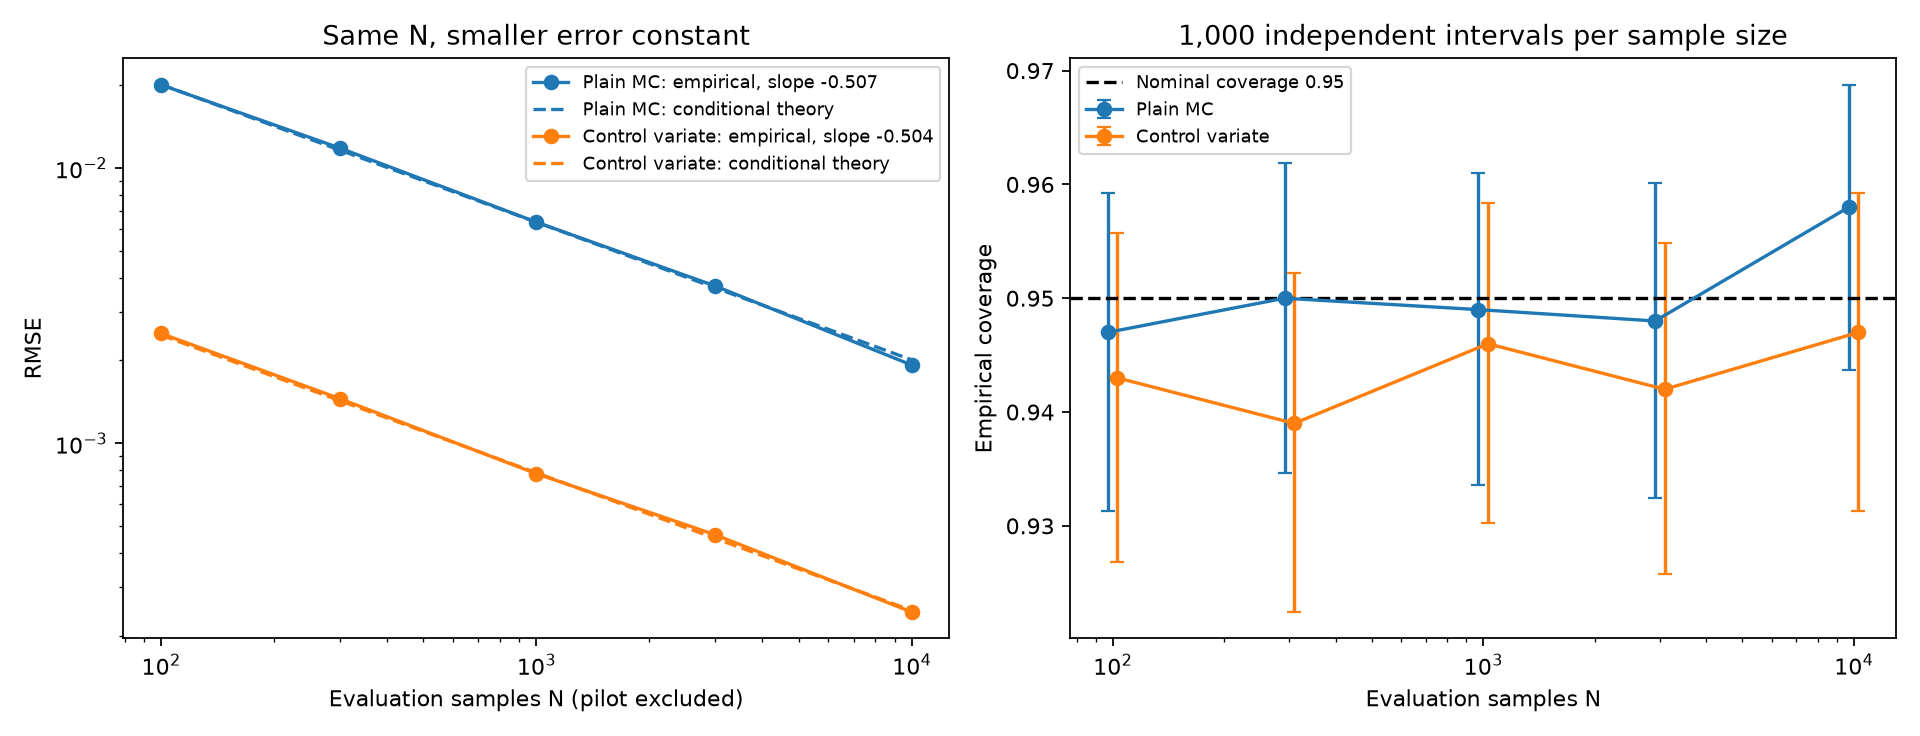

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
for name, label, color, shift in [('plain', 'Plain MC', 'tab:blue', .97),
                                 ('control', 'Control variate', 'tab:orange', 1.03)]:
    rows = [r[name] for r in mc_rows]
    axes[0].loglog(sample_sizes, [r['rmse'] for r in rows], 'o-', color=color,
                   label=f'{label}: empirical, slope {mc_slopes[name]:.3f}')
    axes[0].loglog(sample_sizes, [r['theoretical_rmse'] for r in rows], '--', color=color,
                   label=f'{label}: conditional theory')
    coverage = np.array([r['coverage'] for r in rows])
    lower = np.array([r['coverage_lower'] for r in rows])
    upper = np.array([r['coverage_upper'] for r in rows])
    axes[1].errorbar(sample_sizes*shift, coverage,
                    yerr=[coverage-lower, upper-coverage], fmt='o-', capsize=3,
                    color=color, label=label)
axes[0].set(xlabel='Evaluation samples N (pilot excluded)', ylabel='RMSE', title='Same N, smaller error constant')
axes[1].axhline(.95, ls='--', color='black', label='Nominal coverage 0.95')
axes[1].set(xscale='log', xlabel='Evaluation samples N', ylabel='Empirical coverage',
            title='1,000 independent intervals per sample size')
for ax in axes:
    ax.legend(fontsize=8)
save_figure(fig, 'supplementary_mc_variance_reduction.png')

## 6. Comparison with Theory

In [8]:
coarse = next(r for r in ou_rows if r['method']=='Euler' and r['dt']==steps[0])
fine = next(r for r in ou_rows if r['method']=='Euler' and r['dt']==steps[-1])
print('OU observed relative variance errors:')
print(f"  h={coarse['dt']}: {(coarse['sample_variance']/continuous_variance-1):.2%}")
print(f"  h={fine['dt']}: {(fine['sample_variance']/continuous_variance-1):.2%}")
print('These compare each simulation with continuous theory, not only with its own recursion.')
covered = sum(r['ci_lower'] <= r['theory_variance'] <= r['ci_upper'] for r in ou_rows)
print(f"OU pointwise variance intervals covering their own method target: {covered}/{len(ou_rows)}.")
results['ou']['own_method_intervals_covered'] = covered
print(f"Periodic-chain distance: {markov_runs[-1]['theoretical_tv'][-1]:.1f} even after {markov_steps} steps.")
last = mc_rows[-1]
print(f"At N={last['n']:,}, the squared-RMSE ratio is {last['squared_rmse_ratio']:.2f}.")
for name in ('plain', 'control'):
    row = last[name]
    print(f"  {name} coverage: {row['coverage']:.3f}, Wilson 95% interval "
          f"[{row['coverage_lower']:.3f}, {row['coverage_upper']:.3f}]")
result_path = project_root / 'notes/supplementary_results.json'
result_path.write_text(json.dumps(results, indent=2, allow_nan=False)+'\n', encoding='utf-8')
print('Full parameters, seeds, versions, and numerical tables saved to notes/supplementary_results.json')

OU observed relative variance errors:
  h=1.0: 53.64%
  h=0.03125: 1.28%
These compare each simulation with continuous theory, not only with its own recursion.
OU pointwise variance intervals covering their own method target: 10/12.
Periodic-chain distance: 0.5 even after 160 steps.
At N=10,000, the squared-RMSE ratio is 62.27.
  plain coverage: 0.958, Wilson 95% interval [0.944, 0.969]
  control coverage: 0.947, Wilson 95% interval [0.931, 0.959]
Full parameters, seeds, versions, and numerical tables saved to notes/supplementary_results.json


Read the tables and uncertainty intervals together. Agreement with a discretized
recursion is not sufficient to establish agreement with the SDE. The analytic
OU bias curve has no simulation noise; the endpoint variance estimates do.

In this recorded run, 10 of the 12 OU variance intervals contain their own
method's theoretical variance. Both methods miss at $h=1/8$; the exact solver's
interval excludes the continuous variance there despite its exact transition
law. A pointwise 95% interval does not guarantee coverage for every run or for
all plotted points simultaneously. We retain these misses rather than changing
seeds. They do not establish a step-size trend for the exact solver.

In the Markov plot, exact distances continue decreasing while empirical
distances eventually fluctuate on a scale proportional to $M^{-1/2}$ for $M$
independent paths. The apparent plateau is therefore not evidence that mixing
stops. Values of zero in the empirical distance are clipped to $10^{-6}$ for the
logarithmic plot only. The periodic chain is an intentional counterexample.

The Monte Carlo graph compares empirical RMSE with the prediction for the
coefficient actually obtained from the pilot. Coverage error bars measure
uncertainty in the **coverage experiment**, not the width of a single integral
interval. Small differences from 0.95 must be assessed at the replication scale.

## 7. Interpretation

- **OU:** distinguish sampling error from numerical bias. Increasing path count
  narrows sampling intervals; reducing $h$ changes the target of the Euler
  recursion toward the continuous target. An exact transition provides an
  independent algorithmic benchmark.
- **Markov:** the subdominant eigenvalue determines the speed in this family.
  Stationarity means invariance if initialized in $\pi$; convergence from another
  initial state requires additional conditions. Periodicity exposes this distinction.
- **Monte Carlo:** prior knowledge of an expectation can reduce noise. Independent
  pilot/evaluation sampling makes the unbiasedness argument transparent. Both
  estimators retain the same convergence order. Empirical coverage tests whether
  the normal approximation is useful at the selected sample sizes.

Questions to explain before using these results in a presentation:
Why does an Euler variance interval sometimes exclude the SDE variance?
Why can time-averaged occupancy converge in a periodic chain while its marginals
oscillate? Why must the control coefficient be frozen independently of evaluation
samples in the unbiasedness argument used here?

## 8. Limitations

- Fixed seeds make the experiments reproducible; they are not evidence of
  universal performance. We retain all planned parameter combinations and
  do not select seeds according to whether results agree with theory.
- Three OU batches are pooled independent paths, not three estimates of bias.
  Variance intervals rely on the Gaussian law for these idealized linear models.
  They are pointwise, without correction for multiple comparisons.
- The OU step study evaluates finite-time **variance bias**, not strong path
  error, general nonlinear SDEs, or performance on observed ocean data.
- The Markov eigenvalue formula is specific to this symmetric two-state family.
  Empirical marginals at different times are correlated through shared paths.
- Control-variate comparisons use equal evaluation sample counts. They exclude
  the 5,000-point pilot and extra arithmetic from the horizontal axis, so they are
  not equal-total-cost or wall-clock speed claims. Gains are integrand-dependent.
- Coverage is conditional on one frozen pilot. Testing many new pilots would be
  a further robustness study. Normal intervals are asymptotic and can miscover at
  small sample sizes. Estimated coverage has its own binomial sampling error.
- Numerical agreement supports theory at these tested settings; the derivations
  supply the mathematical justification. No empirical data are analyzed here.